In [7]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 69.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 86.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 85.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 8.4 MB/s eta 0:00:00


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv("stability_surface_box_N2000_grid200.csv")
print(df.head())
print(df.columns)
print(df.shape)

     a    b         c    x         y     z
0  1.0  0.3  0.300000  0.3  0.300000  18.0
1  1.0  0.3  0.303491  0.3  0.303491  19.0
2  1.0  0.3  0.307023  0.3  0.307023  19.0
3  1.0  0.3  0.310597  0.3  0.310597  20.0
4  1.0  0.3  0.314211  0.3  0.314211  20.0
Index(['a', 'b', 'c', 'x', 'y', 'z'], dtype='str')
(40000, 6)


In [5]:
x = df["b"].to_numpy()   # x = b/a, hier direkt b, da a=1 fix
y = df["c"].to_numpy()   # y = c/a
z = df["z"].to_numpy()   # Stabilitätsminimum f*

u = (np.log(x) + np.log(y)) / np.sqrt(2.0)
v = (np.log(x) - np.log(y)) / np.sqrt(2.0)

print("x-range:", x.min(), x.max())
print("y-range:", y.min(), y.max())
print("z-range:", z.min(), z.max())
print("u-range:", u.min(), u.max())
print("v-range:", v.min(), v.max())

x-range: 0.3 3.0
y-range: 0.3 3.0
z-range: 8.0 200.0
u-range: -1.7026746686061074 1.5536723984241865
v-range: -1.6281735335151468 1.6281735335151468


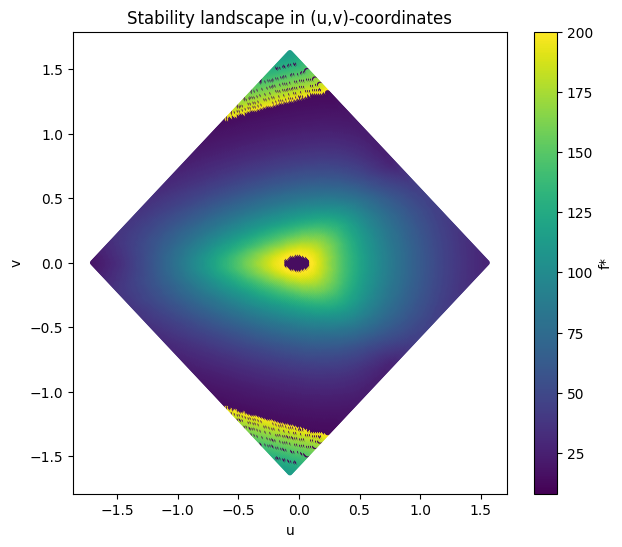

In [9]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(u, v, c=z, s=8)
plt.colorbar(sc, label="f*")
plt.xlabel("u")
plt.ylabel("v")
plt.title("Stability landscape in (u,v)-coordinates")
plt.show()

In [11]:
def poly_model(uv, fmin, a1, a2, a3, b2, b4, c):
    u, v = uv
    return (
        fmin
        + a1 * u
        + a2 * u**2
        + a3 * u**3
        + b2 * v**2
        + b4 * v**4
        + c  * u * v**2
    )

# Startwerte
p0 = [10.0, 0.0, 5.0, 0.0, 5.0, 0.0, 0.0]

params, cov = curve_fit(
    poly_model,
    (u, v),
    z,
    p0=p0,
    maxfev=200000
)

z_pred = poly_model((u, v), *params)
rmse = np.sqrt(np.mean((z - z_pred)**2))
r2 = 1 - np.sum((z - z_pred)**2) / np.sum((z - z.mean())**2)

print("Parameters:")
print("fmin, a1, a2, a3, b2, b4, c =", params)
print("RMSE =", rmse)
print("R^2  =", r2)

Parameters:
fmin, a1, a2, a3, b2, b4, c = [ 137.58914855   15.02824925  -54.89334071  -11.76032516 -198.00957436
   94.85440683  -33.47118514]
RMSE = 27.742295057567173
R^2  = 0.641883419280336


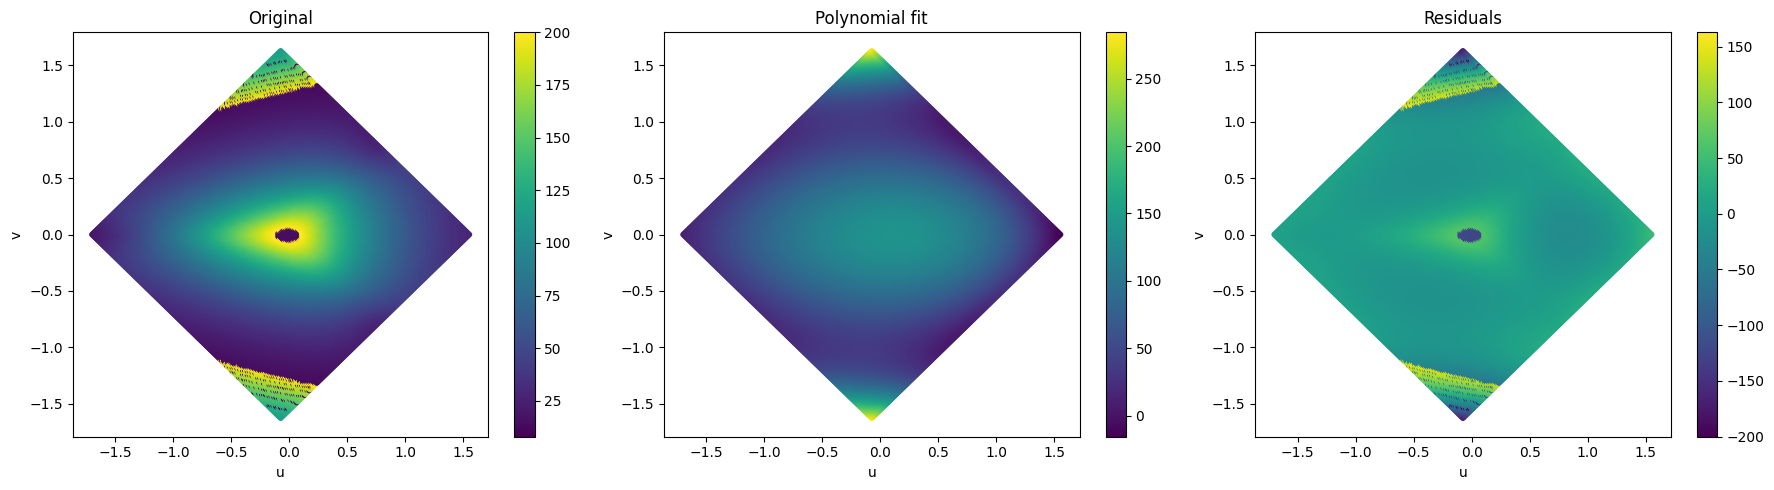

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc0 = axes[0].scatter(u, v, c=z, s=8)
axes[0].set_title("Original")
axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(u, v, c=z_pred, s=8)
axes[1].set_title("Polynomial fit")
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")
plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(u, v, c=(z - z_pred), s=8)
axes[2].set_title("Residuals")
axes[2].set_xlabel("u")
axes[2].set_ylabel("v")
plt.colorbar(sc2, ax=axes[2])

plt.tight_layout()
plt.show()

In [21]:
# 1) Grundmaske: oszillierende Flügel abschneiden
mask_base = np.abs(v) < 1.1

# 2) Randzone definieren
edge_zone = (np.abs(v) > 1.0) & (np.abs(v) < 1.2)

# 3) In der Randzone nur unplausible Abstürze entfernen
# Schwelle zuerst konservativ wählen
z_edge = z[edge_zone]
thr = np.percentile(z_edge, 10)   # z.B. unterste 10% in der Randzone

mask_drop = ~(edge_zone & (z < thr))

# 4) Gesamtmaske
mask = mask_base & mask_drop

print("Kept points:", mask.sum(), "of", len(mask))
print("Threshold in edge zone:", thr)

Kept points: 35676 of 40000
Threshold in edge zone: 16.0


In [22]:
params_masked, _ = curve_fit(
    poly_model,
    (u[mask], v[mask]),
    z[mask],
    p0=p0,
    maxfev=200000
)

z_pred_masked = poly_model((u[mask], v[mask]), *params_masked)

rmse_masked = np.sqrt(np.mean((z[mask] - z_pred_masked)**2))
r2_masked = 1 - np.sum((z[mask] - z_pred_masked)**2) / np.sum((z[mask] - z[mask].mean())**2)

print("Masked fit parameters:")
print(params_masked)
print("RMSE =", rmse_masked)
print("R^2  =", r2_masked)

Masked fit parameters:
[ 141.57156345    7.49942959  -55.72800504   -8.46994583 -223.01399966
  112.47302497   -4.46951298]
RMSE = 15.347705319273926
R^2  = 0.8586097656784264


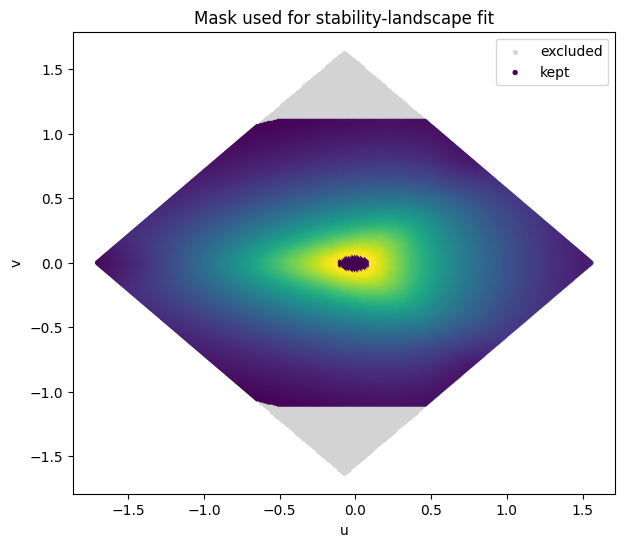

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(u, v, c="lightgray", s=6, label="excluded")
plt.scatter(u[mask], v[mask], c=z[mask], s=8, label="kept")
plt.xlabel("u")
plt.ylabel("v")
plt.title("Mask used for stability-landscape fit")
plt.legend()
plt.show()

In [24]:
def poly_crater_model(uv, f0, a1, a2, a3, b2, b4, c, D, uc, su, sv):
    u, v = uv
    poly = (
        f0
        + a1*u
        + a2*u**2
        + a3*u**3
        + b2*v**2
        + b4*v**4
        + c*u*v**2
    )
    crater = D * np.exp(
        -((u - uc)**2)/(2*su**2) - (v**2)/(2*sv**2)
    )
    return poly - crater

In [25]:
p0_crater = [
    141.5,   # f0
    7.5,     # a1
    -55.7,   # a2
    -8.5,    # a3
    -223.0,  # b2
    112.5,   # b4
    -4.5,    # c
    30.0,    # D  (Tiefe des Kraters)
    0.0,     # uc (nahe Zentrum)
    0.35,    # su
    0.35     # sv
]

In [26]:
params_crater, _ = curve_fit(
    poly_crater_model,
    (u[mask], v[mask]),
    z[mask],
    p0=p0_crater,
    maxfev=500000
)

z_pred_crater = poly_crater_model((u[mask], v[mask]), *params_crater)

rmse_crater = np.sqrt(np.mean((z[mask] - z_pred_crater)**2))
r2_crater = 1 - np.sum((z[mask] - z_pred_crater)**2) / np.sum((z[mask] - z[mask].mean())**2)

print("Crater model parameters:")
print(params_crater)
print("RMSE =", rmse_crater)
print("R^2 =", r2_crater)

Crater model parameters:
[ 5.85907334e+01  7.70348664e+00 -1.41781233e+01 -5.68115391e+00
 -4.01574427e+01  6.64031431e+00  2.43952340e+00 -1.14498455e+02
 -3.78933433e-02  5.86038036e-01  3.28419389e-01]
RMSE = 11.66927923981539
R^2 = 0.9182626459293073
